# Racetrack 5.12

## 1) Building the racetrack!

In [1]:
# defining the region
width = 17
height = 28

In [2]:
import numpy as np
track = np.zeros((height, width), dtype = bool)

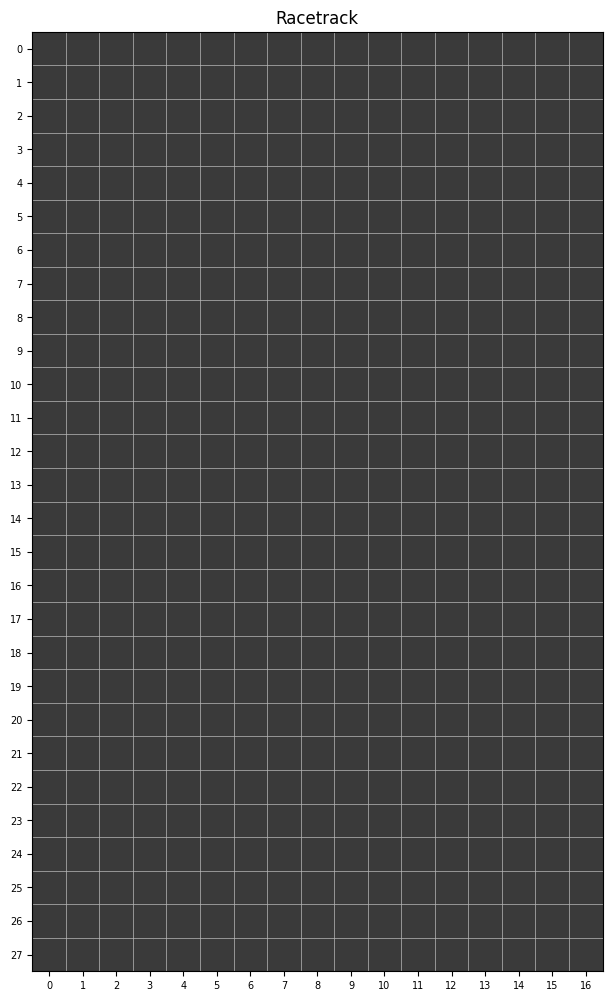

In [3]:
import matplotlib.pyplot as plt
from draw import draw_grid

draw_grid(track, title="Racetrack")
plt.show()

In [4]:
# defining start and finish lines
start_cells = [(x, 27) for x in range(3,9)]
finish_cells = [(16, y) for y  in range(0,6)]

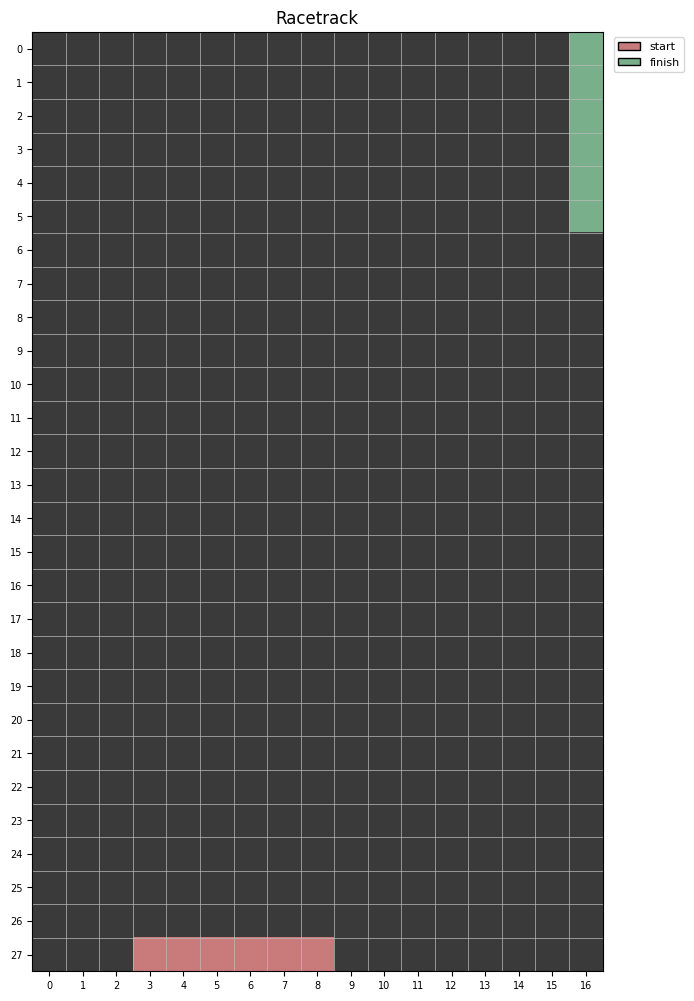

In [5]:
layers = {
    "start":  (start_cells,  "#c97a7a"),
    "finish": (finish_cells, "#7aaf8c"),
}
draw_grid(track, layers, title="Racetrack")
plt.show()

we have the track now, but all cells are marked 0 (off track) as seen through black in the plot

Therefore now we can start defining what IS track using smaller sections of the track (refer track I from the book)

The idea is to break down the track into smaller rectangles so we can use those rectangles to define the track

In [6]:
rectangles = [
    # (x0, x1, y0, y1)
    ( 3, 8, 0,27),
    ( 3,16, 0, 5),
    ( 2, 2, 1,24),
    ( 1, 1, 3,17),
    ( 0, 0, 4,13),
    ( 9, 9, 6, 6)
    
]

In [7]:
for x0, x1, y0, y1 in rectangles:
    track[y0:y1+1, x0:x1+1] = True

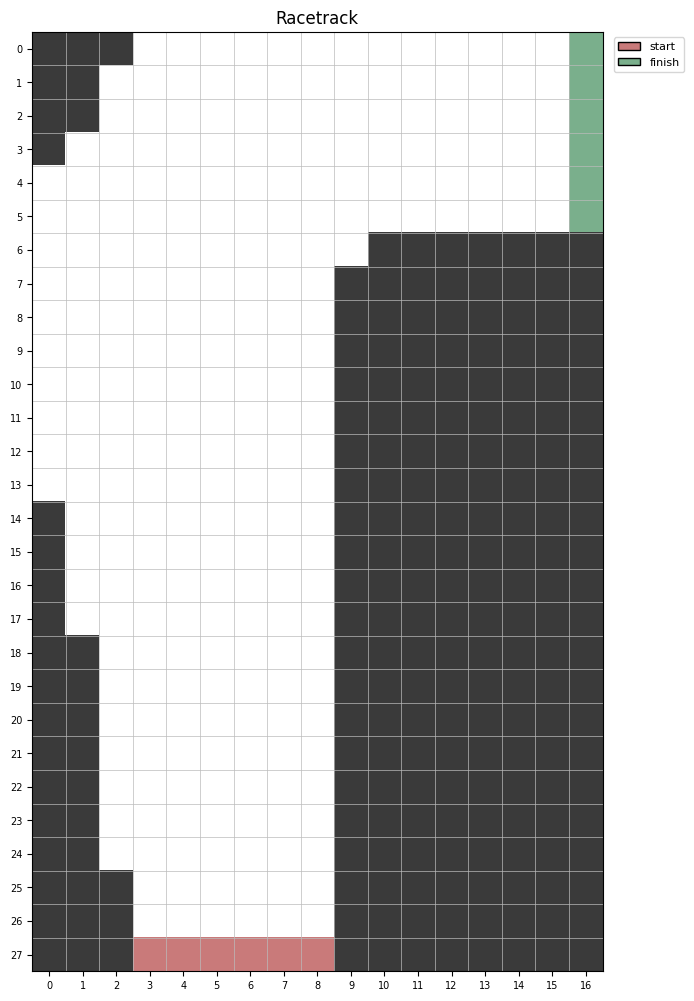

In [8]:
draw_grid(track, layers, title="Racetrack")
plt.show()

## 2)Gym Environment

In [9]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [29]:
class RaceTrackEnv(gym.Env):

    def __init__(self, track, start_cells, finish_cells, noise = 0.1, max_steps = 1000):
        super().__init__()
        self.track = track
        self.start_cells = start_cells
        self.finish_cells = finish_cells
        
        self.noise = noise
        self.max_steps = max_steps
        

        self.actions = [
            (-1, -1), (-1,  0), (-1,  1),
            ( 0, -1), ( 0,  0), ( 0,  1),
            ( 1, -1), ( 1,  0), ( 1,  1)
        ]
        self.action_space = spaces.Discrete(9)
        h, w = track.shape
        self.observation_space = spaces.MultiDiscrete([
            w, h, 5, 5
        ])
        
        self.step_count = 0
        

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)
        self._respawn()
        self.step_count = 0
        
        return np.array(self.state, dtype= np.int32), {}

    def step(self, action):
        terminated = False
        x, y, vx, vy = map(int, self.state)
        
        vx, vy = self._update_velocity(
            x,y,vx,vy, action
        )
        path = self._path_cells(x, y, vx, vy)
        result = self._classify_path(path)
        
        if result == "finish":
            
            finish_x, finish_y = next(
                (x,y) for x,y in path
                if (x,y) in self.finish_cells
            )
            self.state = np.array(
                [finish_x, finish_y, vx,vy],
                dtype=np.int32
            )
            terminated = True
        elif result == "crash":
            self._respawn()
            terminated = False
        
        else: # "ok"
            new_x = x + vx
            new_y = y - vy
            
            self.state = np.array(
                [new_x, new_y, vx, vy],
                dtype= np.int32
            )
            
        self.step_count +=1
        truncated = self.step_count >= self.max_steps
            
        obs = np.array(self.state, dtype= np.int32)
        
        return obs, -1, terminated, truncated, {}
        
        
    ## HELPERS
    
    def _respawn(self):
        x, y = self.start_cells[
            self.np_random.integers(len(self.start_cells))
        ]
        self.state = np.array([x,y,0,0], dtype=np.int32)
    
    def _update_velocity(self, x, y, vx, vy, action):
        dvx, dvy = self.actions[action]
        
        if self.np_random.random() < self.noise:
            dvx, dvy = 0, 0
        
        new_vx = vx + dvx
        new_vy = vy + dvy
        
        #invalid velocity  keeps older velocity
        if not (0<=new_vx<=4 and 0<=new_vy<= 4):
            return vx, vy
        
        if (new_vx, new_vy) == (0, 0) and (x, y) not in self.start_cells:
            return vx, vy
        
        return new_vx, new_vy
            
    def _path_cells(self, x, y, vx, vy):
        n = max(vx, vy)
        
        if n == 0:
            return[]
        cells = []
        
        for i in range(1, n+1):
            px = x + (i/n) *vx
            py = y - (i/n) *vy
            
            cell_x = int(np.floor(px+0.5))
            cell_y = int(np.floor(py+0.5))
            
            cells.append((cell_x, cell_y))
        
        return cells
    
    def _classify_path(self, cells):
        h, w = self.track.shape
        
        for x,y in cells:
            if (x,y) in self.finish_cells:
                return "finish"
            if not (0<= x < w and 0<= y < h):
                return "crash"
            if not self.track[y,x]:
                return "crash"
            
        return "ok"
            
                


Now we just run some tests and see what's up

In [36]:
from gymnasium.utils.env_checker import check_env

env = RaceTrackEnv(
    track,
    start_cells,
    finish_cells,
    noise=0.1,
    max_steps=200
)

check_env(env)

In [33]:
env = RaceTrackEnv(
    track,
    start_cells,
    finish_cells,
    noise=0,
    max_steps=200
)

paths = {}

for episode in range(5):
    obs, _ = env.reset(seed=episode)

    path = [tuple(obs[:2])]

    for _ in range(200):
        action = env.action_space.sample()

        obs, reward, terminated, truncated, info = env.step(action)

        path.append(tuple(obs[:2]))

        if terminated or truncated:
            break

    paths[f"episode {episode + 1}"] = (
        path,
        None  # replace with whatever color format your helper expects
    )

In [34]:
colors = ["red", "blue", "orange", "purple", "cyan"]

paths = {}

for episode in range(5):
    obs, _ = env.reset(seed=episode)
    path = [tuple(obs[:2])]

    for _ in range(200):
        obs, _, terminated, truncated, _ = env.step(
            env.action_space.sample()
        )

        path.append(tuple(obs[:2]))

        if terminated or truncated:
            break

    paths[f"episode {episode + 1}"] = (
        path,
        colors[episode]
    )

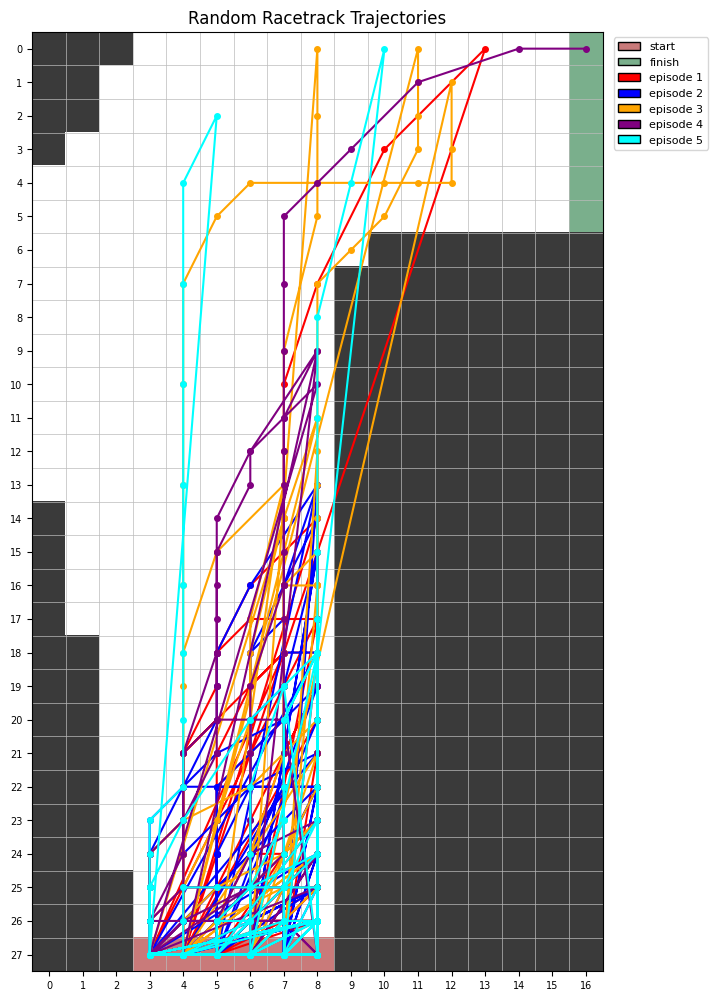

In [35]:
draw_grid(
    track,
    layers={
        "start": (start_cells, "#c97a7a"),
        "finish": (finish_cells, "#7aaf8c")
    },
    paths=paths,
    title="Random Racetrack Trajectories"
)

plt.show()

And good! notice how the agent respawns to start line when crashing which is required for learning since if it terminates on crashing, the agent would learn prioritize crash to minimize the -1 reward per step. Respawn ensures it doesnt end there!

## 3) Now we do Monte Carlo!

### a) On-Policy Monte carlo Control!


## Monte Carlo Control
## Monte Carlo Control

Repeat forever (for each episode):

1. Generate an episode following $\pi$:

   $$
   S_0, A_0, R_1, \ldots, S_{T-1}, A_{T-1}, R_T
   $$

2. Initialize:

   $$
   G \leftarrow 0
   $$

3. Loop for each step of the episode, $t = T-1, T-2, \ldots, 0$:

   $$
   G \leftarrow \gamma G + R_{t+1}
   $$

   Unless the pair $(S_t,A_t)$ appears in
   $(S_0,A_0),\ldots,(S_{t-1},A_{t-1})$:

   - Append $G$ to $\mathrm{Returns}(S_t,A_t)$:

     $$
     \mathrm{Returns}(S_t,A_t)
     \leftarrow
     \mathrm{Returns}(S_t,A_t) \cup \{G\}
     $$

   - Update the action value:

     $$
     Q(S_t,A_t)
     \leftarrow
     \operatorname{average}(\mathrm{Returns}(S_t,A_t))
     $$

   - Find the greedy action:

     $$
     A^* \leftarrow \arg\max_a Q(S_t,a)
     $$

   - For every $a \in \mathcal{A}(S_t)$, improve the $\epsilon$-soft policy:

     $$
     \pi(a|S_t) \leftarrow
     \begin{cases}
     1-\epsilon+\dfrac{\epsilon}{|\mathcal{A}(S_t)|},
     & \text{if } a=A^* \\[6pt]
     \dfrac{\epsilon}{|\mathcal{A}(S_t)|},
     & \text{if } a\neq A^*
     \end{cases}
     $$

#### Initialize

- $\pi$ — an arbitrary $\epsilon$-soft policy
- $Q(s,a) \in \mathbb{R}$, arbitrarily, for all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$
- $\text{Returns}(s,a) \leftarrow \text{empty list}$, for all $s \in \mathcal{S}$, $a \in \mathcal{A}(s)$


In [42]:
n_actions = env.action_space.n

In [49]:
def pi(x, y, vx, vy):
    return np.full(n_actions, 1 / n_actions)

In [50]:
Q = np.zeros((
    track.shape[1],
    track.shape[0],
    5,
    5,
    n_actions
))

In [51]:
Returns = np.empty(Q.shape, dtype= object)
for index in np.ndindex(Q.shape):
    Returns[index] = []

Now the loop

In [55]:
def sample_actions(policy, state):
    x, y, vx, vy = state

    probabilities = policy(x, y, vx, vy)

    return np.random.choice(
        n_actions,
        p=probabilities
    )

In [56]:
# generate episode
def generate_episode(env,policy):
    episode = []
    state, _ = env.reset()
    
    while True:
        action = sample_actions(policy, state)
        next_state, reward, terminated, truncated , _ = env.step(action)
        episode.append((state.copy(), action, reward))
        state = next_state
        
        if terminated or truncated:
            break
        
    return episode


In [64]:
def calculate_returns(episode, gamma = 1.0):
    G = 0 
    returns = []
    for state, action, reward in reversed(episode):
        G = gamma * G + reward
        
        returns.reverse()
        
    return returns

